# Etap 1 — Dane i eksploracja datasetu (Jigsaw Toxic Comment)

**Cel:** przygotować dane i zrozumieć klasy, balans, przykładowe komentarze oraz charakterystykę multi-label.

**Źródło:** [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge) — plik `train.csv`.

**Etykiety (multi-label):** `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`.

---

### Jak umieścić dane

Pobierz `train.csv` z Kaggle i skopiuj do:

`data/raw/train.csv`

(względem **korzenia repozytorium**, nie katalogu `ml/`).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.titlesize"] = 13

LABEL_COLS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "docker-compose.yml").is_file() and (p / "ml").is_dir():
            return p
        if (p / "backend").is_dir() and (p / "data" / "raw").is_dir():
            return p
        if (p / "data" / "raw" / "train.csv").is_file():
            return p
    return start

REPO_ROOT = find_project_root()
DATA_PATH = REPO_ROOT / "data" / "raw" / "train.csv"
print("REPO_ROOT:", REPO_ROOT)
print("DATA_PATH:", DATA_PATH)

REPO_ROOT: I:\GreatProjects\toxic-comment-detector
DATA_PATH: I:\GreatProjects\toxic-comment-detector\data\raw\train.csv


## 2.1 Ładowanie danych

In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Brak pliku {DATA_PATH}. Pobierz train.csv z Kaggle i zapisz w data/raw/."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
print("shape:", df.shape)
print("\nkolumny:", list(df.columns))
df.info()

shape: (159571, 8)

kolumny: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
missing_labels = [c for c in LABEL_COLS if c not in df.columns]
if missing_labels:
    raise ValueError(f"Brak oczekiwanych kolumn etykiet: {missing_labels}")

if "comment_text" not in df.columns:
    raise ValueError("Oczekiwana kolumna 'comment_text'.")

df[LABEL_COLS] = df[LABEL_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
df["comment_text"] = df["comment_text"].astype(str)

## EDA — rozkład klas (liczba pozytywnych przykładów na etykietę)

W zadaniu multi-label jeden komentarz może mieć wiele `1` w różnych kolumnach — sumy po kolumnach **nie** sumują się do liczby wierszy.

In [5]:
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)
label_pct = (label_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"positives": label_counts, "percent_of_rows": label_pct})
summary

,positives,percent_of_rows
toxic,15294,9.58
obscene,8449,5.29
insult,7877,4.94
severe_toxic,1595,1.00
identity_hate,1405,0.88
threat,478,0.30


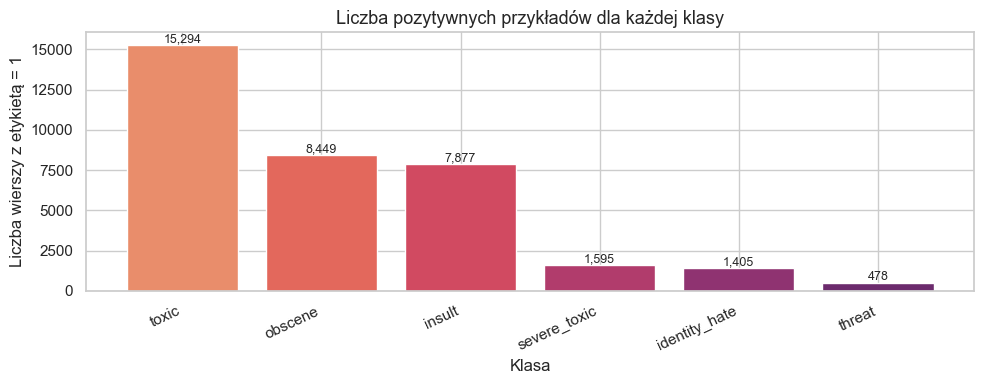

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(label_counts))
colors = sns.color_palette("flare", n_colors=len(label_counts))
ax.bar(x, label_counts.values, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(label_counts.index, rotation=25, ha="right")
ax.set_title("Liczba pozytywnych przykładów dla każdej klasy")
ax.set_xlabel("Klasa")
ax.set_ylabel("Liczba wierszy z etykietą = 1")
for i, v in enumerate(label_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Długość komentarzy (znaki)

In [7]:
df["char_len"] = df["comment_text"].str.len()
df["word_len"] = df["comment_text"].str.split().str.len()

df["char_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
50%         205.000000
90%         889.000000
95%        1355.000000
99%        3444.000000
max        5000.000000
Name: char_len, dtype: float64

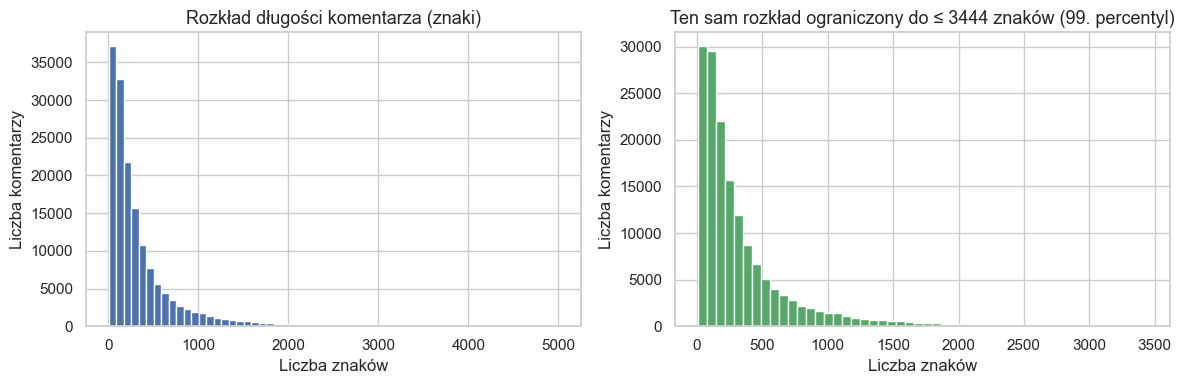

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["char_len"], bins=60, color="#4c72b0", edgecolor="white")
axes[0].set_title("Rozkład długości komentarza (znaki)")
axes[0].set_xlabel("Liczba znaków")
axes[0].set_ylabel("Liczba komentarzy")

cap = int(df["char_len"].quantile(0.99))
subset = df.loc[df["char_len"] <= cap, "char_len"]
axes[1].hist(subset, bins=50, color="#55a868", edgecolor="white")
axes[1].set_title(f"Ten sam rozkład ograniczony do ≤ {cap} znaków (99. percentyl)")
axes[1].set_xlabel("Liczba znaków")
axes[1].set_ylabel("Liczba komentarzy")

plt.tight_layout()
plt.show()

## Multi-label: ile etykiet na komentarz?

In [9]:
df["label_count"] = df[LABEL_COLS].sum(axis=1)
label_count_dist = df["label_count"].value_counts().sort_index()
label_count_dist

label_count
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

Komentarze z ≥2 etykietami: 9,865 (6.18%)


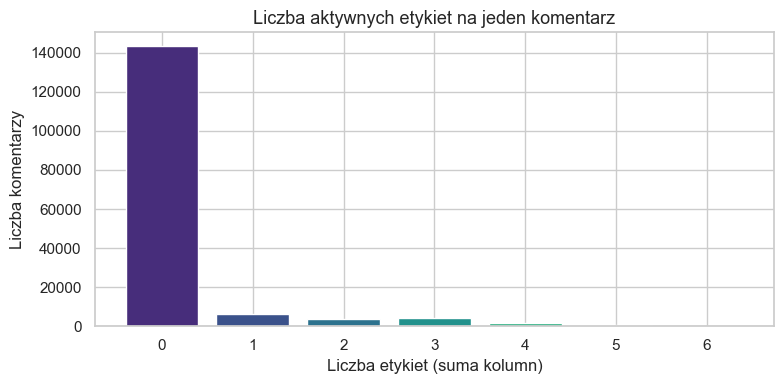

In [10]:
multi_rows = int((df["label_count"] >= 2).sum())
multi_pct = round(multi_rows / len(df) * 100, 2)
print(f"Komentarze z ≥2 etykietami: {multi_rows:,} ({multi_pct}%)")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(label_count_dist))
ax.bar(
    x,
    label_count_dist.values,
    color=sns.color_palette("viridis", n_colors=len(label_count_dist)),
)
ax.set_xticks(x)
ax.set_xticklabels(label_count_dist.index.astype(str))
ax.set_title("Liczba aktywnych etykiet na jeden komentarz")
ax.set_xlabel("Liczba etykiet (suma kolumn)")
ax.set_ylabel("Liczba komentarzy")
plt.tight_layout()
plt.show()

## Procent „toksycznych” komentarzy

- **Dowolna toksyczność:** `1` w którejkolwiek z 6 kolumn.
- **Kolumna `toxic`:** tylko pierwsza etykieta (często raportuje się oba widoki).

% z ≥1 etykietą (dowolna klasa): 10.17%
% z etykietą `toxic` == 1: 9.58%


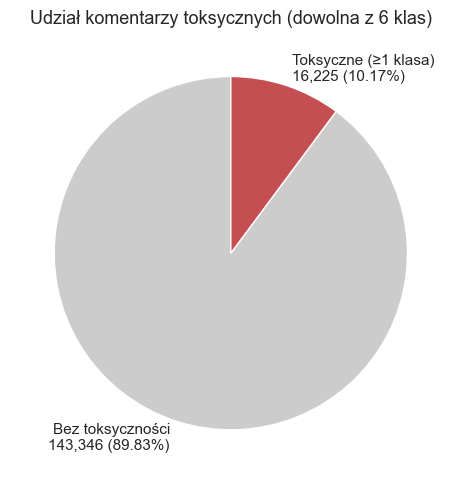

In [11]:
any_toxic = df[LABEL_COLS].max(axis=1).astype(bool)
col_toxic = df["toxic"].astype(bool)

pct_any = round(any_toxic.mean() * 100, 2)
pct_toxic_col = round(col_toxic.mean() * 100, 2)

print(f"% z ≥1 etykietą (dowolna klasa): {pct_any}%")
print(f"% z etykietą `toxic` == 1: {pct_toxic_col}%")

fig, ax = plt.subplots(figsize=(5, 5))
sizes = [int((~any_toxic).sum()), int(any_toxic.sum())]
labels = [f"Bez toksyczności\n{sizes[0]:,} ({100 - pct_any:.2f}%)", f"Toksyczne (≥1 klasa)\n{sizes[1]:,} ({pct_any}%)"]
ax.pie(sizes, labels=labels, autopct="", startangle=90, colors=["#cccccc", "#c44e52"])
ax.set_title("Udział komentarzy toksycznych (dowolna z 6 klas)")
plt.tight_layout()
plt.show()

## Przykłady: toksyczne vs nietoksyczne

Losowe próbki (ziarno ustawione dla powtarzalności).

In [12]:
clean = df.loc[df["label_count"] == 0, "comment_text"]
toxic_any = df.loc[df["label_count"] > 0, ["comment_text", *LABEL_COLS]]

print("=== Przykłady nietoksyczne (bez etykiet) ===")
for i, text in enumerate(clean.sample(n=min(3, len(clean)), random_state=42).tolist(), start=1):
    snippet = text.replace("\n", " ")[:400]
    print(f"{i}. {snippet}\n")

print("=== Przykłady toksyczne (≥1 etykieta) ===")
sample = toxic_any.sample(n=min(5, len(toxic_any)), random_state=42)
for idx, row in sample.iterrows():
    active = [c for c in LABEL_COLS if int(row[c]) == 1]
    snippet = str(row["comment_text"]).replace("\n", " ")[:400]
    print(f"[{', '.join(active)}]\n{snippet}\n")

=== Przykłady nietoksyczne (bez etykiet) ===
1. "  Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both with articles and ""arbitration or sanctions,"" such as the RfAr/Clarification and a dispute over my last block, which was ostensibly about the sanction and which I hope can be resolved without much fu

2. Are you trying to dispute that fact?

3. SWOT analysis   This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm going to remove anything sourced to it. Leaving this note in case there are objections.  (talk)

=== Przykłady toksyczne (≥1 etykieta) ===
[toxic]
" I was talking about them running any check they want on ME to disprove your claims.  I didn't know where you lived until you were silly enough to post an IP and 

## Krótkie podsumowanie (do raportu)

- **Klasy:** 6 etykiet multi-label; rozkład pozytywnych obserwacji powyżej (wykres słupkowy).
- **Balans:** silna dysproporcja — większość komentarzy bez etykiet; `severe_toxic` i `identity_hate` są rzadsze.
- **Długości:** histogram znaków + wersja obcięta do percentyla 99 (czytelniejszy ogon).
- **Multi-label:** rozkład liczby etykiet na przykład; odsetek przykładów z wieloma etykietami wydrukowany.
- **Toksyczność ogółem:** wykres kołowy dla „≥1 klasa” oraz procent samej kolumny `toxic`.

Możesz wyeksportować wykresy (np. prawy klik → Save image) do sprawozdania.